# Clasificación - Análisis
El objetivo de este notebook es análizar los resultados arrojados por el random search realizado en 09-clasificacion-random_search.ipynb y elegir la mejor configuración que clasifique nuestro dataset entre outliers y no outliers.

In [53]:
from xgboost import XGBClassifier

from sklearn import set_config
set_config(transform_output="pandas")

from src.config import TREE_BASED_CONFIG_NORMAL
from src.model_evaluation import evaluate_classifiers_cv
from src.pipeline import build_feature_pipeline
%load_ext autoreload
%autoreload 2
import pandas as pd

from src.plots import plot_classifier_results, plot_classifier_comparison
from src.constants import COLS, DEV_SET_CLEAN_PATH

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Dataset Desbalanceado

In [12]:
# Función para agregar una columna con un ID único para cada configuración (nos va a servir para identificar a la configuración)
def add_id_to_results(results):
    results = results.reset_index(drop=True)
    results.insert(0, 'config_id', range(1, len(results) + 1))
    return results

In [13]:
df_results_unbalanced = pd.read_csv("../results/random_search/clf_full.csv")
df_results_unbalanced = add_id_to_results(df_results_unbalanced)

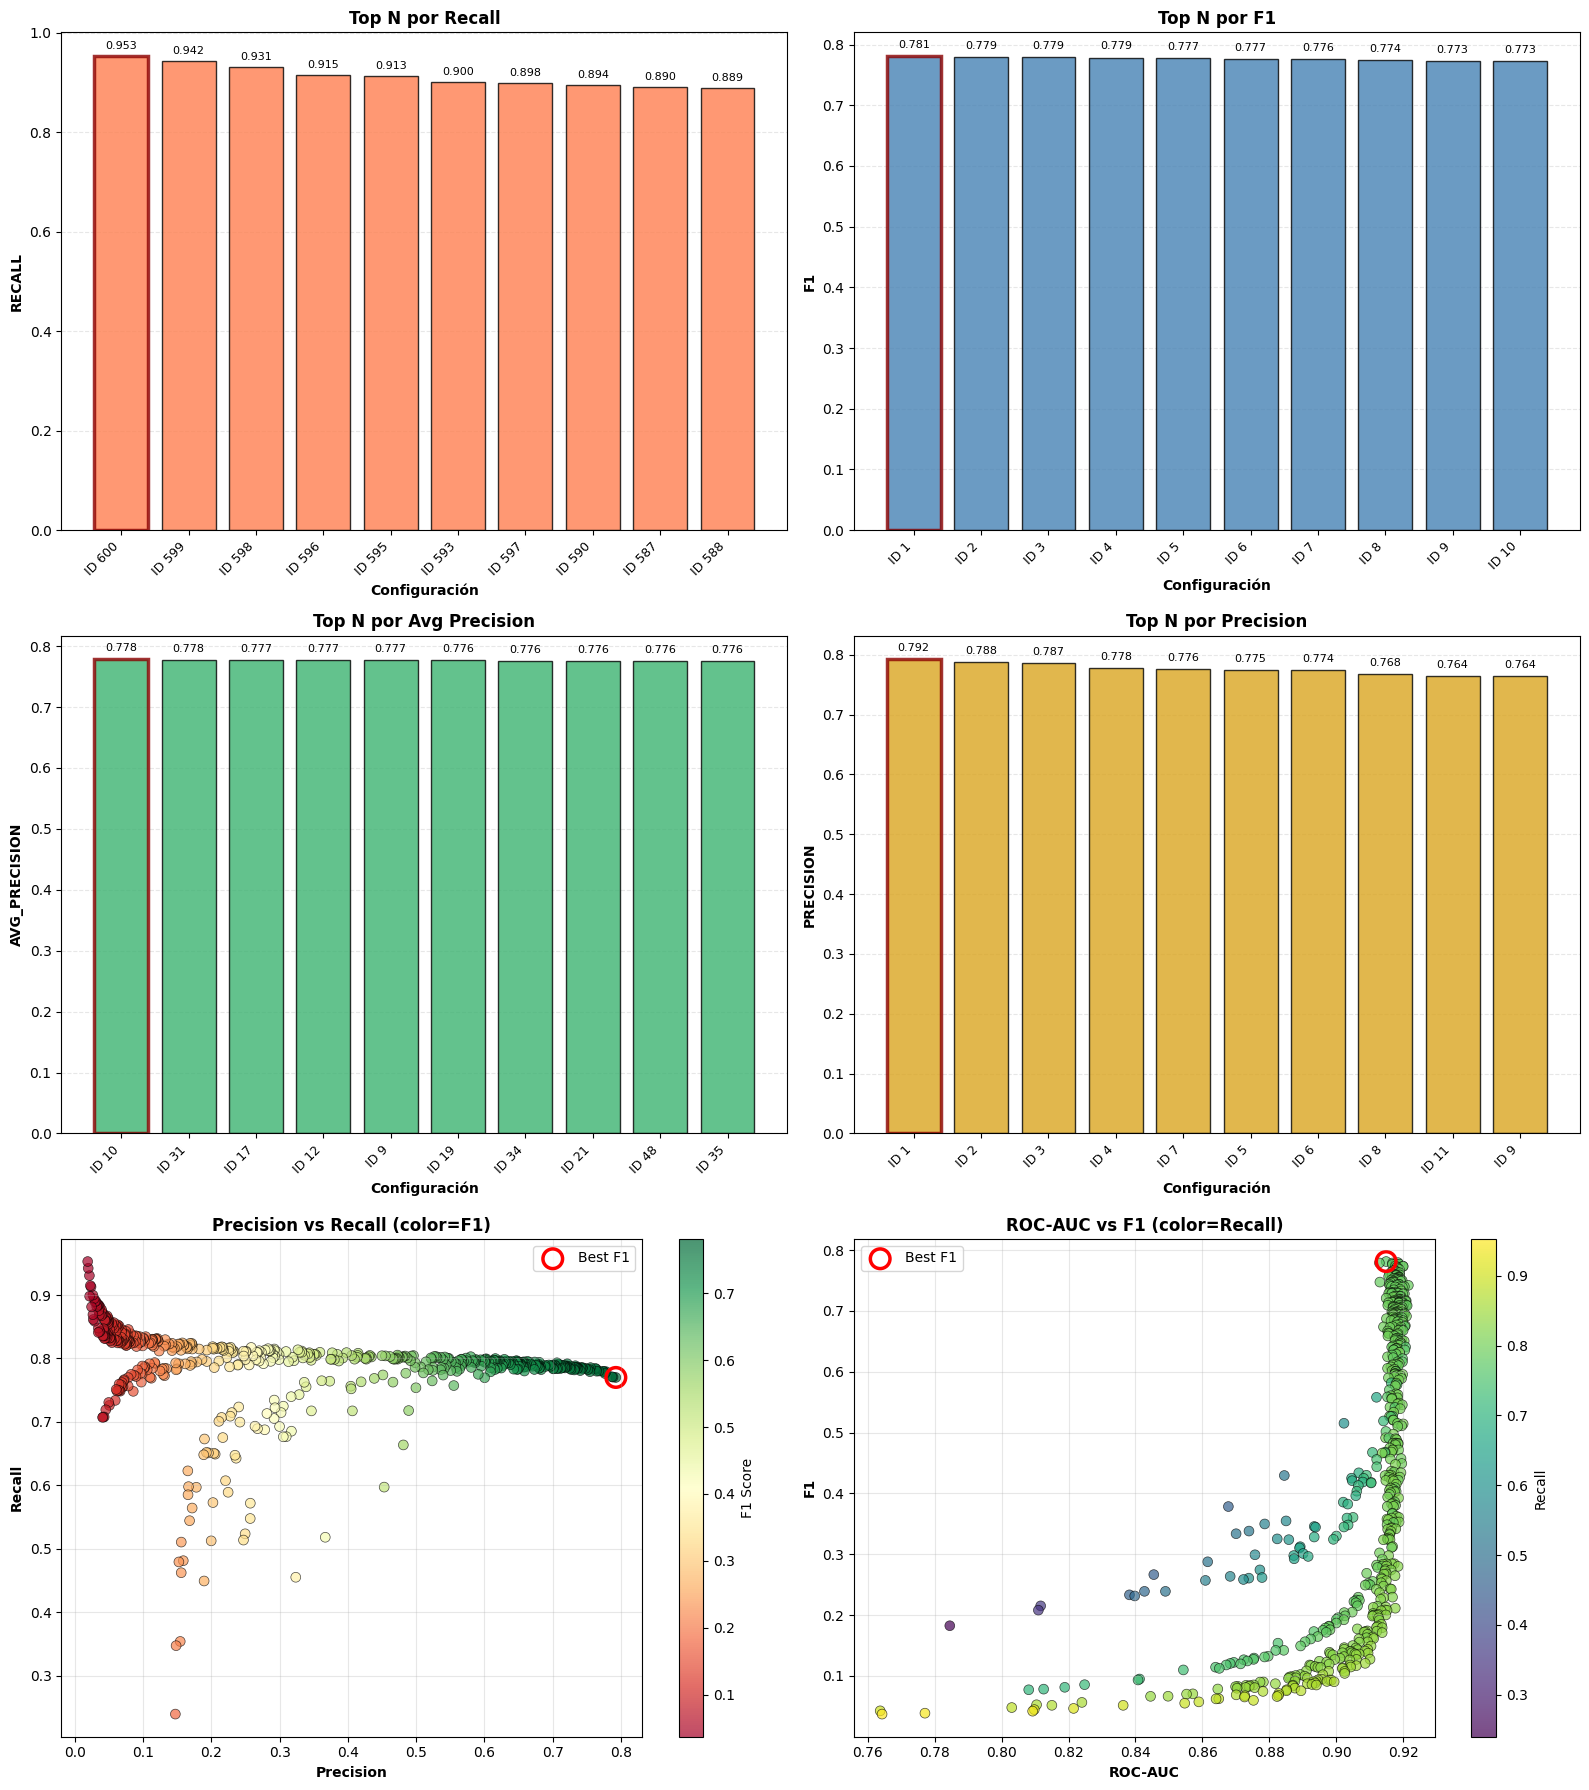


🏆 MEJOR MODELO (por F1):
Config ID: 1
F1:        0.7811
Precision: 0.7924
Recall:    0.7701
ROC-AUC:   0.9149
Avg Prec:  0.7724


In [34]:
plot_classifier_results(df_results_unbalanced, top_n=10)

In [20]:
# Filtrar modelos con buen balance
df_filtered = df_results_unbalanced[
    (df_results_unbalanced['test_recall'] >= 0.80) &  # Detectar 85%+ outliers
    (df_results_unbalanced['test_precision'] >= 0.50) &  # Al menos 50% precision
    (df_results_unbalanced['f1_gap_%'] <= 50)  # Gap tolerable
    ].sort_values('test_f1', ascending=False)
print(f"Modelos que cumplen criterios: {len(df_filtered)}")
# Ver top 5
cols_to_show = ['config_id', 'test_recall', 'test_precision', 'test_f1',
                'test_roc_auc', 'f1_gap_%']
df_filtered[cols_to_show].head(10)

Modelos que cumplen criterios: 10


,config_id,test_recall,test_precision,test_f1,test_roc_auc,f1_gap_%
147,148,0.802855,0.579931,0.673320,0.919374,-16.955610
151,152,0.800640,0.573044,0.667927,0.918647,-18.329791
166,167,0.800148,0.547906,0.650410,0.920311,-16.504129
167,168,0.800393,0.546069,0.649191,0.919056,-17.414877
168,169,0.802362,0.541934,0.646901,0.919381,-17.312383
172,173,0.801870,0.535743,0.642283,0.916999,-18.094596
175,176,0.801131,0.530649,0.638419,0.918058,-17.658662
176,177,0.803101,0.529081,0.637888,0.918356,-18.570236
178,179,0.803101,0.526397,0.635913,0.917222,-18.199267
182,183,0.800886,0.521597,0.631704,0.918918,-19.008249


In [23]:
df_results_unbalanced[cols_to_show].head()

,config_id,test_recall,test_precision,test_f1,test_roc_auc,f1_gap_%
0,1,0.770119,0.792425,0.781096,0.914917,-20.011211
1,2,0.770611,0.788290,0.779346,0.918440,-18.651184
2,3,0.771103,0.786701,0.778784,0.912905,-20.406126
3,4,0.779226,0.778175,0.778665,0.916795,-18.329520
4,5,0.779718,0.774630,0.777151,0.917769,-17.412340


La configuración ganadora para el dataset desbalanceado es la que tiene config_id 2. Si bien no maximiza la métrica más importante (recall) tiene un buen balance con un alto F1 score. Los modelos que maximizan el recall tienen F1 casi cercano a cero.

In [43]:
unbalanced_winner_config = {
    'colsample_bytree': 0.7792021248679025,
    'gamma': 0.21211100462348814,
    'learning_rate': 0.18220733316799984,
    'max_depth': 9,
    'min_child_weight': 3,
    'n_estimators': 800,
    'reg_alpha': 0.034060934302257206,
    'reg_lambda': 2.3433032099706312,
    'scale_pos_weight': 65.63106079251784,
    'subsample': 0.8704869304553342,
    'random_state': 42,
}

## 2. Dataset Balanceado

In [31]:
df_results_balanced = pd.read_csv("../results/random_search/clf_balanced.csv")
# df_results_balanced = add_id_to_results(df_results_balanced)
df_results_balanced.head()

,Unnamed: 0,config_id,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,...,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision,test_f1_std,train_f1,train_accuracy,overfit_gap_%
0,0,1,0.575837,0.155861,0.057213,9,1,900,0.613634,3.570320,...,0.970315,0.844328,0.831410,0.837790,0.931274,0.864086,0.009680,0.976157,0.995495,16.515788
1,1,2,0.638435,0.023032,0.186857,9,2,900,1.788150,4.978672,...,0.969249,0.838034,0.826734,0.832214,0.930035,0.861827,0.012048,0.986914,0.997555,18.589020
2,2,3,0.779202,0.212111,0.182207,9,3,800,0.034061,2.343303,...,0.969044,0.834663,0.828456,0.831491,0.928472,0.861104,0.006442,0.990553,0.998241,19.129678
3,3,4,0.882325,0.073348,0.141161,9,6,800,0.984480,0.268862,...,0.968318,0.826346,0.831164,0.828667,0.928223,0.862481,0.007604,0.986435,0.997464,19.038801
4,4,5,0.984706,0.129067,0.134780,9,1,700,0.392621,4.849105,...,0.967819,0.823669,0.828703,0.826054,0.928885,0.861596,0.007594,0.987904,0.997742,19.593165


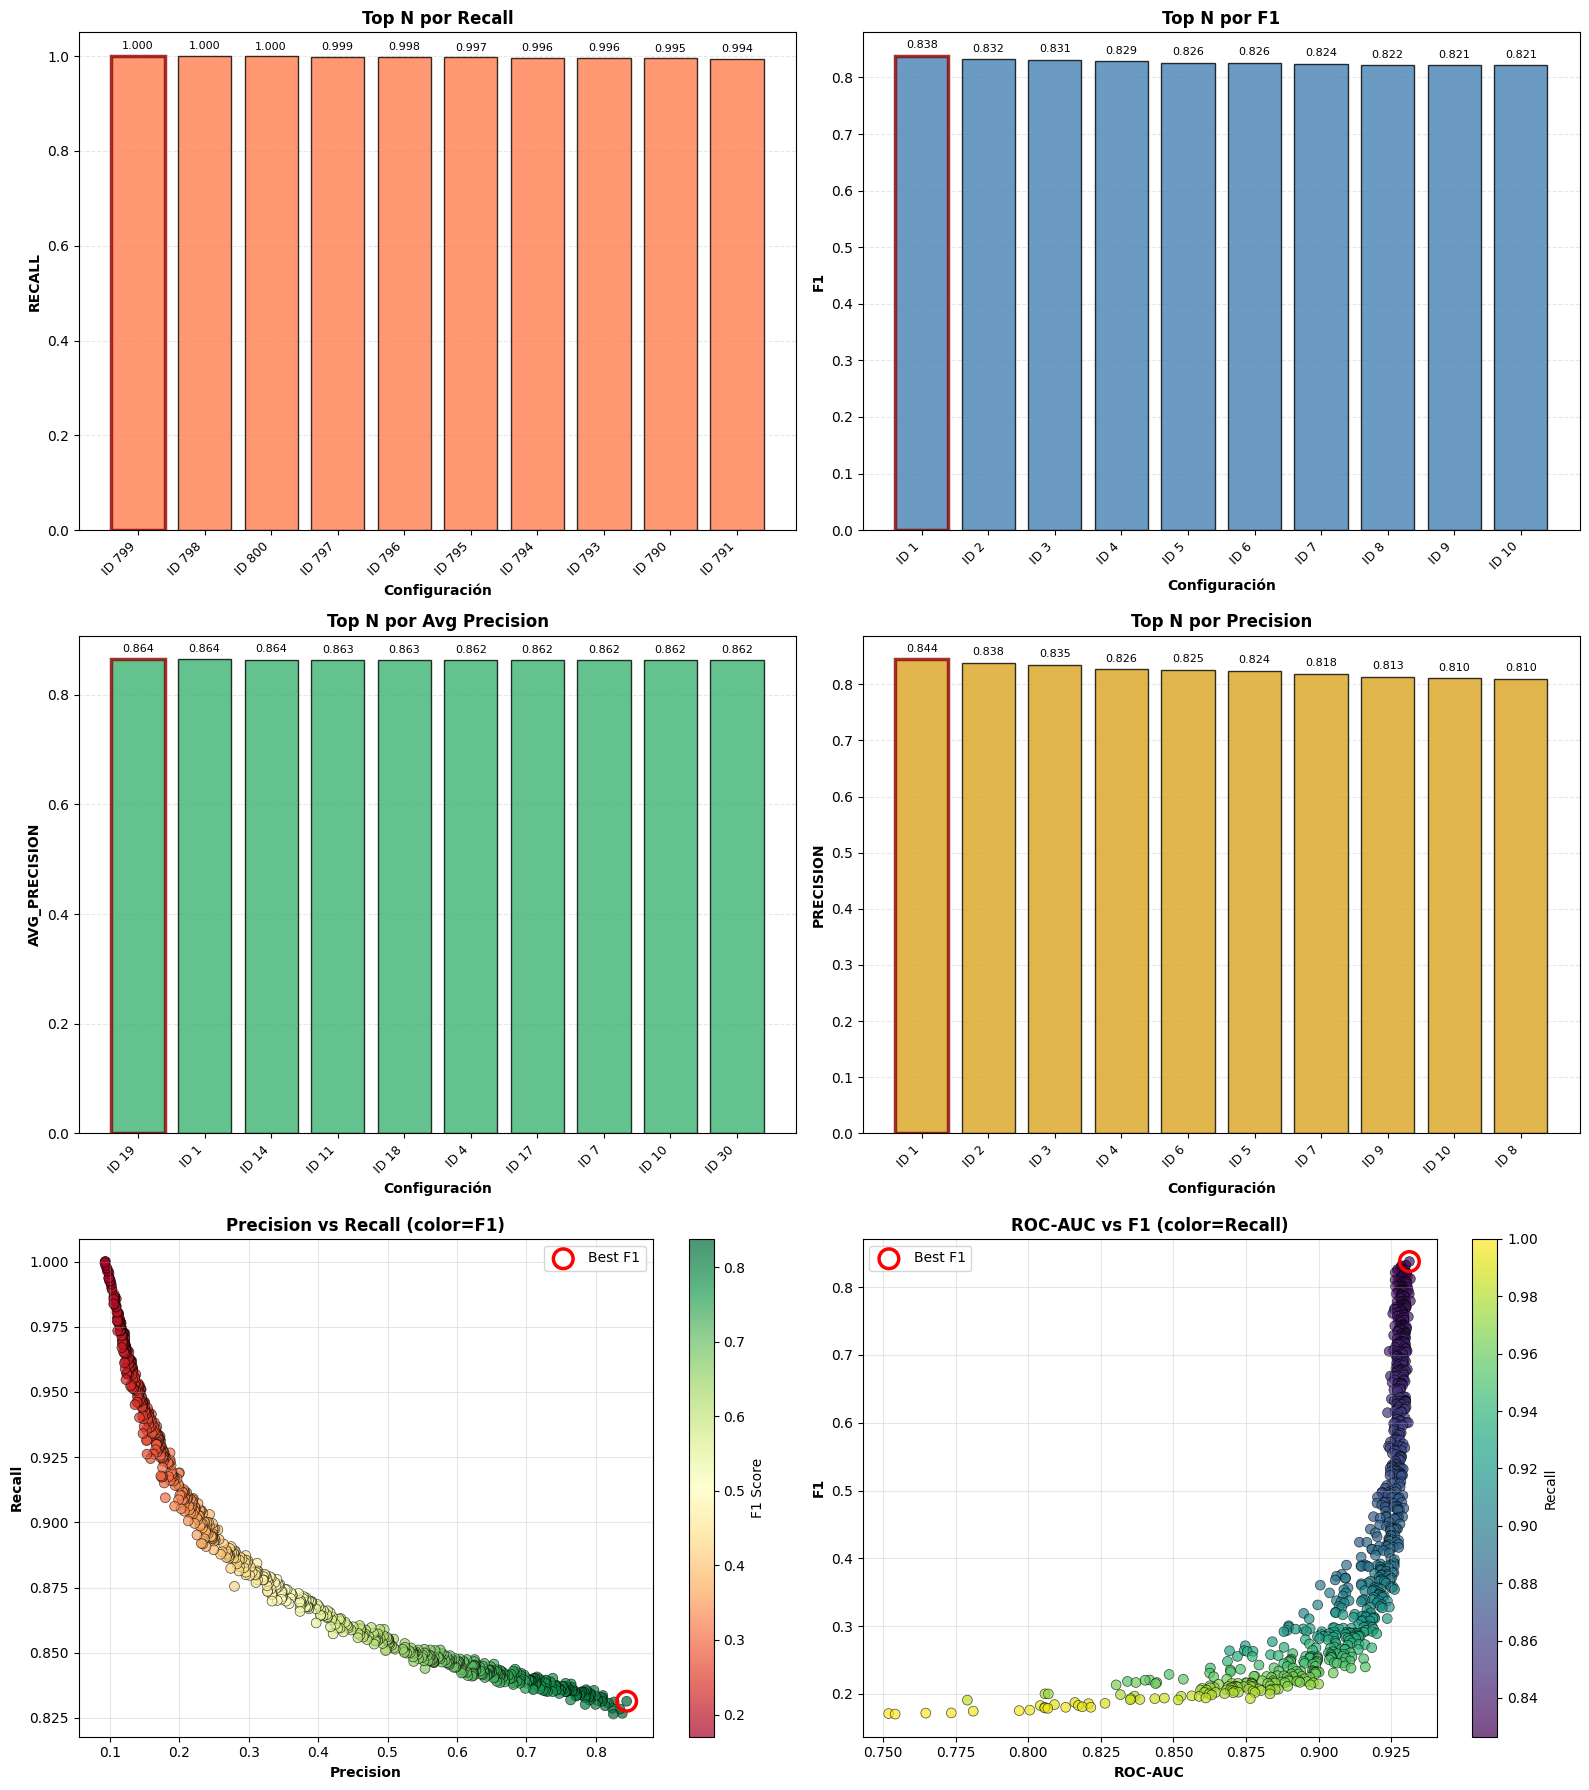


🏆 MEJOR MODELO (por F1):
Config ID: 1
F1:        0.8378
Precision: 0.8443
Recall:    0.8314
ROC-AUC:   0.9313
Avg Prec:  0.8641


In [33]:
plot_classifier_results(df_results_balanced, top_n=10)

In [36]:
df_results_balanced.head()

,Unnamed: 0,config_id,colsample_bytree,gamma,learning_rate,max_depth,min_child_weight,n_estimators,reg_alpha,reg_lambda,...,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision,test_f1_std,train_f1,train_accuracy,overfit_gap_%
0,0,1,0.575837,0.155861,0.057213,9,1,900,0.613634,3.570320,...,0.970315,0.844328,0.831410,0.837790,0.931274,0.864086,0.009680,0.976157,0.995495,16.515788
1,1,2,0.638435,0.023032,0.186857,9,2,900,1.788150,4.978672,...,0.969249,0.838034,0.826734,0.832214,0.930035,0.861827,0.012048,0.986914,0.997555,18.589020
2,2,3,0.779202,0.212111,0.182207,9,3,800,0.034061,2.343303,...,0.969044,0.834663,0.828456,0.831491,0.928472,0.861104,0.006442,0.990553,0.998241,19.129678
3,3,4,0.882325,0.073348,0.141161,9,6,800,0.984480,0.268862,...,0.968318,0.826346,0.831164,0.828667,0.928223,0.862481,0.007604,0.986435,0.997464,19.038801
4,4,5,0.984706,0.129067,0.134780,9,1,700,0.392621,4.849105,...,0.967819,0.823669,0.828703,0.826054,0.928885,0.861596,0.007594,0.987904,0.997742,19.593165


El primer modelo (config_id = 1) es el que sacó las mejores métricas

In [41]:
balanced_winner_config = {
    'colsample_bytree': 0.575837,
    'gamma': 0.155861,
    'learning_rate': 0.057213,
    'max_depth': 9,
    'min_child_weight': 1,
    'n_estimators': 900,
    'reg_alpha': 0.613634,
    'reg_lambda': 3.570320,
    'scale_pos_weight': 32.815530,
    'subsample': 0.938383,
    'random_state': 42,
}

# Comparación

Comparemos mediante cross validation ambos modelos de clasificación sobre el dataset completo para elegir el mejor

In [44]:
clf_models = {
    "unbalanced": XGBClassifier(**unbalanced_winner_config),
    "balanced": XGBClassifier(**balanced_winner_config),
}

In [46]:
df_full = pd.read_csv("../" + DEV_SET_CLEAN_PATH)
threshold = df_full[COLS.TARGET].quantile(0.985)
df_full['is_outlier'] = (df_full[COLS.TARGET] >= threshold).astype(int)

class_dist = df_full['is_outlier'].value_counts(normalize=True).sort_index()
print(f"  Normales (0):  {class_dist[0]:.1%} ({(df_full['is_outlier'] == 0).sum():,})")
print(f"  Outliers (1):  {class_dist[1]:.1%} ({(df_full['is_outlier'] == 1).sum():,})")

# Features y target
X_clf = df_full.drop(columns=[COLS.TARGET, 'is_outlier'])
y_clf = df_full['is_outlier']

  Normales (0):  98.5% (266,659)
  Outliers (1):  1.5% (4,063)


In [51]:
clf_results = evaluate_classifiers_cv(
    clf_models,
    X=X_clf,
    y=y_clf,
    feature_pipeline=build_feature_pipeline(TREE_BASED_CONFIG_NORMAL),
    n_splits=5,
)


🔄 Ejecutando 5-Fold Stratified CV (Clasificación)...

Entrenando unbalanced...
  ✓ F1:        0.7954 ± 0.0044
  ✓ Recall:    0.7965 ± 0.0087
  ✓ Precision: 0.7944 ± 0.0080
  ✓ ROC-AUC:   0.9240

Entrenando balanced...
  ✓ F1:        0.7806 ± 0.0038
  ✓ Recall:    0.8122 ± 0.0061
  ✓ Precision: 0.7515 ± 0.0077
  ✓ ROC-AUC:   0.9262



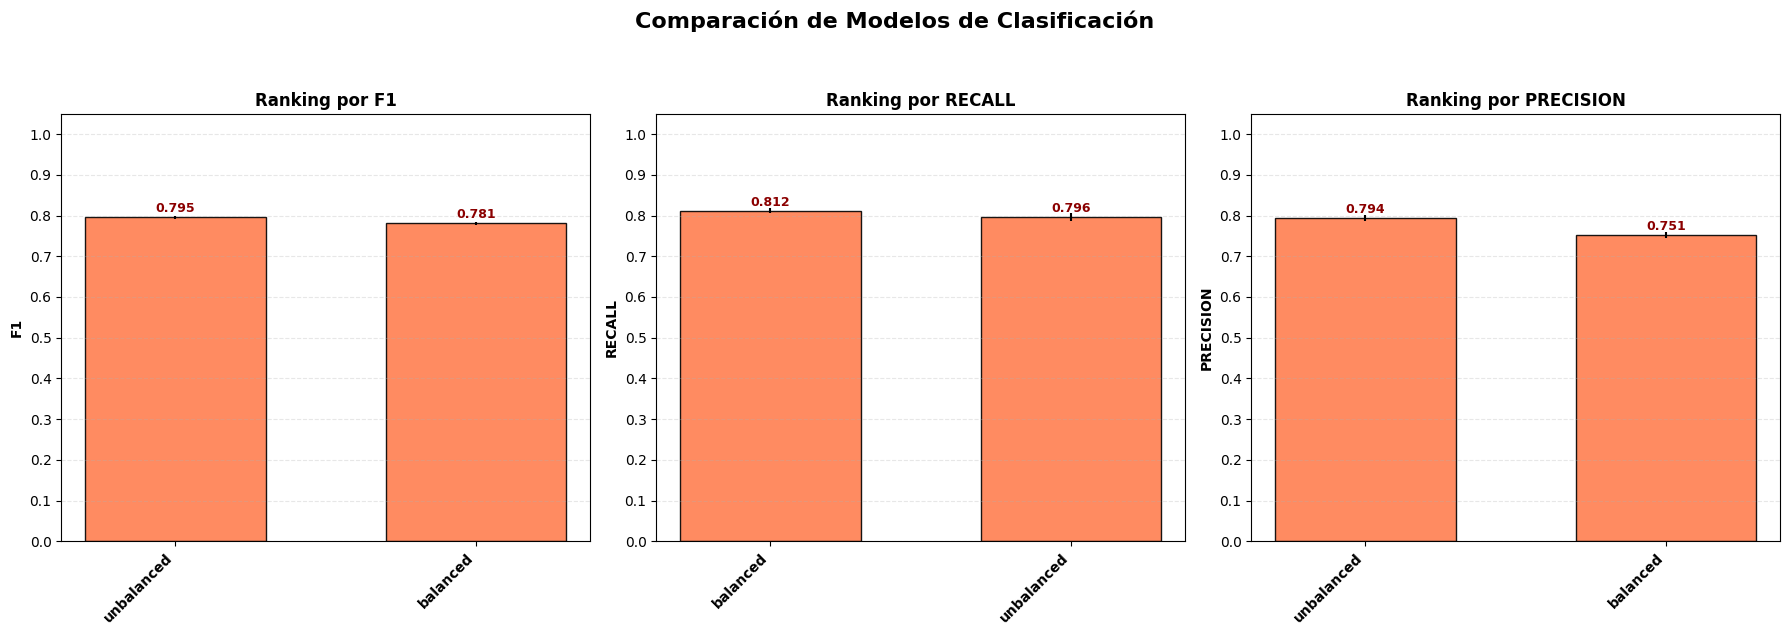

In [57]:
plot_classifier_comparison(clf_results)

El modelo con el dataset desbalanceado es el que mejor funcionó en todas las métricas. Vamos a usar ese modelo para el testeo.